# 01_连通性判定

演示如何从 CSV 读取圆柱顶点，进行截断、连通性判定（阈值 1.8 nm）。请在运行前确保该仓库的 src/ 在 Python path，或在此 notebook 顶部调整 sys.path。

In [3]:
import os
import sys

# 获取当前工作目录（notebooks/）
current_dir = os.getcwd()
# 回到项目根目录（假设 notebook 在 notebooks/ 下）
repo_root = os.path.dirname(current_dir)
if repo_root not in sys.path:
    sys.path.append(repo_root)

print(f"项目根目录: {repo_root}")
import numpy as np
import pandas as pd
from src.geometry import Cylinder
from src.truncation import split_cylinder_by_box
from src.connectivity import build_connectivity
import matplotlib.pyplot as plt


# 1. 设置支持中文的字体（Windows 常用的是黑体 SimHei 或者微软雅黑 Microsoft YaHei）
plt.rcParams['font.sans-serif'] = ['SimHei']  

# 2. 解决负号 '-' 显示为方块的问题
plt.rcParams['axes.unicode_minus'] = False  
%matplotlib inline

项目根目录: f:\数模专用\2026_HuaShuCup_Problem_A


## 参数（按题目给定）

In [4]:
L = 10000.0  # nm, box size  
r = 30.0    # nm, cylinder radius  
h = 5000.0  # nm, cylinder length  
thresh = 1.8  # nm, surface-to-surface connect threshold

## 读取 CSV（示例）  
假设 CSV 列头为：顶点1_X, 顶点1_Y, 顶点1_Z, 顶点2_X, 顶点2_Y, 顶点2_Z

若你的 CSV 没有表头，请用：pd.read_csv(csv_path, header=None) 并按列索引映射坐标。

In [5]:
#csv_path = 'data/raw/附件_组1.csv'  # 改成你的路径
#df = pd.read_csv(csv_path)
#df.head()
import os
# repo_root 已经在前面定义过了
csv_path = os.path.join(repo_root, 'data/raw/附件_组1.csv')

df = pd.read_csv(csv_path, encoding='gbk',header=1)  # 用第二行（X/Y/Z）作表头
# 手动设置多级列索引
df.columns = pd.MultiIndex.from_tuples([
    ('顶点1', 'X'),
    ('顶点1', 'Y'),
    ('顶点1', 'Z'),
    ('顶点2', 'X'),
    ('顶点2', 'Y'),
    ('顶点2', 'Z')
])
df.head(15)

顶点1                                  顶点2                        
              X           Y           Z            X           Y           Z
0  -5000.000000 -123.595140 -413.210771 -2588.094239  263.800243 -256.916005
1  -5000.000000  260.638630  -45.535533 -2697.575082  420.228820  141.734027
2  -5000.000000  273.505297 -144.677940 -3939.159696  318.937665 -118.265179
3  -4192.318606  261.813019 -199.977020   806.624527  321.530792 -283.651025
4  -2777.977438 -159.004834 -249.729794  2215.332098   97.705863 -280.705585
5  -2262.039518 -250.253829  441.667837  -843.854488 -277.554922  500.000000
6   -843.854488 -277.554922 -500.000000  2732.812454 -346.408362 -352.886108
7    577.038076 -500.000000 -306.636482  5000.000000 -472.318119 -258.403555
8   1066.964138  105.066057 -242.602516  5000.000000  273.505297 -144.677940
9   2330.732535   75.621130 -262.642524  5000.000000  260.638630  -45.535533
10  2656.520725 -500.000000  434.928592  3660.688088 -338.712687  500.000000
11  3660.688088 -338.712687 -500.000000  5000.000000 -123.595140 -413.210771

In [6]:
# 兼容有/无表头: 尝试检测列名
cols = df.columns.tolist()
if len(cols) >= 6:
    # try to find numeric columns
    arr = df.iloc[:, :6].to_numpy(dtype=float)
else:
    raise RuntimeError('CSV must have at least 6 numeric columns for two vertices')
cyls = []
for i, row in enumerate(arr):
    p0 = row[0:3]
    p1 = row[3:6]
    cyls.append(Cylinder(p0, p1, r, id=i))
len(cyls)

12

对每个圆柱做截断并合并片段，然后判断连通性

In [7]:
segments = []
for c in cyls:
    segs = split_cylinder_by_box(c, L)
    segments.extend(segs)
print('原始圆柱:', len(cyls), '截断后片段:', len(segments))
connected, uf = build_connectivity(segments, L, thresh)
print('是否导通:', connected)

原始圆柱: 12 截断后片段: 12
是否导通: False


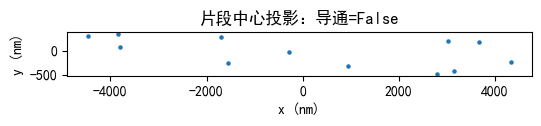

In [8]:
 # 简单可视化：xy 平面投影的圆心与连通簇（仅示意）
centers = np.array([s.center() for s in segments])
xs = centers[:,0]
ys = centers[:,1]
plt.figure(figsize=(6,6))
plt.scatter(xs, ys, s=5)
plt.xlabel('x (nm)')
plt.ylabel('y (nm)')
plt.title(f'片段中心投影：导通={connected}')
plt.gca().set_aspect('equal', 'box')
plt.show()

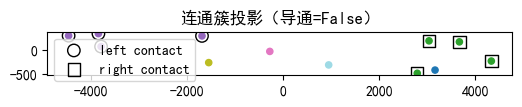

In [9]:
# 为每个片段/原粒子着色显示连通簇（示意）
# 先收集 segments、uf（notebook 中已有 segments, uf, connected）
labels = []
for idx, s in enumerate(segments):
    labels.append(uf.find(idx))
# 把标签压缩成连续整数用于调色
unique = {v:i for i,v in enumerate(sorted(set(labels), key=lambda x: str(x)))}
colors = [unique[l] for l in labels]
centers = np.array([s.center() for s in segments])
plt.figure(figsize=(6,6))
plt.scatter(centers[:,0], centers[:,1], c=colors, s=20, cmap='tab20')
# 标示连接到左右平面的点
left_pts = [i for i,s in enumerate(segments) if uf.find(i) == uf.find(('PLANE','LEFT'))]
right_pts = [i for i,s in enumerate(segments) if uf.find(i) == uf.find(('PLANE','RIGHT'))]
if left_pts:
    plt.scatter(centers[left_pts,0], centers[left_pts,1], edgecolor='k', facecolor='none', s=80, label='left contact')
if right_pts:
    plt.scatter(centers[right_pts,0], centers[right_pts,1], marker='s', edgecolor='k', facecolor='none', s=80, label='right contact')
plt.legend()
plt.title(f'连通簇投影（导通={connected}）')
plt.gca().set_aspect('equal', 'box')
plt.show()

**smoke test** 

In [10]:
# smoke test: 构造两根很近的短柱，检查它们彼此是否连通（而非电极间连通）
from src.geometry import Cylinder
from src.truncation import split_cylinder_by_box
from src.connectivity import build_connectivity, are_indices_connected, are_ids_connected

L = 10000.0; r = 30.0; thresh = 1.8
c1 = Cylinder(np.array([-100.0,0,0]), np.array([-100.0,0,500.0]), r, id=0)
c2 = Cylinder(np.array([-100.0,0,500.0 + (r*2) - 1.0]), np.array([-100.0,0,1000.0]), r, id=1)  # 留 1 nm 表面间隙

segs = []
for c in (c1, c2):
    segs.extend(split_cylinder_by_box(c, L))

connected_planes, uf = build_connectivity(segs, L, thresh)

# 检查两个圆柱的任意一段是否被并到同一集合中
# segments 在 build_connectivity 中按传入顺序索引，所以这里第一根圆柱的片段索引从 0 开始
# 如果 split_cylinder_by_box 为每根只返回一段，则索引 0 和 1 对应两根原始圆柱
assert are_indices_connected(uf, 0, 1), "Smoke test failed: 两个接近的圆柱应被判定为连通"
print('Smoke test passed: 两个圆柱在同一连通簇')

Smoke test passed: 两个圆柱在同一连通簇


# 微构体2的导通情况

In [11]:
#csv_path = 'data/raw/附件_组2.csv'  # 改成你的路径
#df = pd.read_csv(csv_path)
#df.head()
import os
# repo_root 已经在前面定义过了
csv_path = os.path.join(repo_root, 'data/raw/附件_组2.csv')

df = pd.read_csv(csv_path, encoding='gbk',header=1)  # 用第二行（X/Y/Z）作表头
# 手动设置多级列索引
df.columns = pd.MultiIndex.from_tuples([
    ('顶点1', 'X'),
    ('顶点1', 'Y'),
    ('顶点1', 'Z'),
    ('顶点2', 'X'),
    ('顶点2', 'Y'),
    ('顶点2', 'Z')
])
df.head()

顶点1                                  顶点2                        
        X           Y           Z            X           Y           Z
0 -5000.0 -460.898289 -273.232451 -3512.125945 -404.979103 -500.000000
1 -5000.0 -192.583780   50.286199  -826.711283  226.126990 -500.000000
2 -5000.0 -143.414420  218.690227 -3181.838088  151.850100  318.205895
3 -5000.0  -31.804363 -200.103934 -1929.532384  108.400845   -0.786883
4 -5000.0  -24.393913 -161.974770 -2024.416090 -500.000000 -313.165070

In [12]:
# 兼容有/无表头: 尝试检测列名
cols = df.columns.tolist()
if len(cols) >= 6:
    # try to find numeric columns
    arr = df.iloc[:, :6].to_numpy(dtype=float)
else:
    raise RuntimeError('CSV must have at least 6 numeric columns for two vertices')
cyls = []
for i, row in enumerate(arr):
    p0 = row[0:3]
    p1 = row[3:6]
    cyls.append(Cylinder(p0, p1, r, id=i))
len(cyls)

49

In [13]:
segments = []
for c in cyls:
    segs = split_cylinder_by_box(c, L)
    segments.extend(segs)
print('原始圆柱:', len(cyls), '截断后片段:', len(segments))
connected, uf = build_connectivity(segments, L, thresh)
print('是否导通:', connected)

原始圆柱: 49 截断后片段: 49
是否导通: True


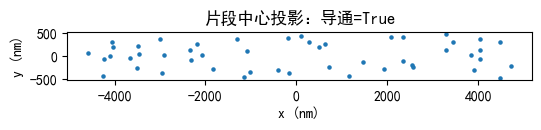

In [14]:
 # 简单可视化：xy 平面投影的圆心与连通簇（仅示意）
centers = np.array([s.center() for s in segments])
xs = centers[:,0]
ys = centers[:,1]
plt.figure(figsize=(6,6))
plt.scatter(xs, ys, s=5)
plt.xlabel('x (nm)')
plt.ylabel('y (nm)')
plt.title(f'片段中心投影：导通={connected}')
plt.gca().set_aspect('equal', 'box')
plt.show()

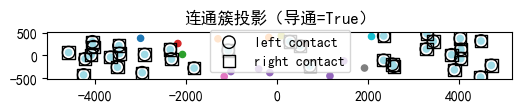

In [15]:
# 为每个片段/原粒子着色显示连通簇（示意）
# 先收集 segments、uf（notebook 中已有 segments, uf, connected）
labels = []
for idx, s in enumerate(segments):
    labels.append(uf.find(idx))
# 把标签压缩成连续整数用于调色
unique = {v:i for i,v in enumerate(sorted(set(labels), key=lambda x: str(x)))}
colors = [unique[l] for l in labels]
centers = np.array([s.center() for s in segments])
plt.figure(figsize=(6,6))
plt.scatter(centers[:,0], centers[:,1], c=colors, s=20, cmap='tab20')
# 标示连接到左右平面的点
left_pts = [i for i,s in enumerate(segments) if uf.find(i) == uf.find(('PLANE','LEFT'))]
right_pts = [i for i,s in enumerate(segments) if uf.find(i) == uf.find(('PLANE','RIGHT'))]
if left_pts:
    plt.scatter(centers[left_pts,0], centers[left_pts,1], edgecolor='k', facecolor='none', s=80, label='left contact')
if right_pts:
    plt.scatter(centers[right_pts,0], centers[right_pts,1], marker='s', edgecolor='k', facecolor='none', s=80, label='right contact')
plt.legend()
plt.title(f'连通簇投影（导通={connected}）')
plt.gca().set_aspect('equal', 'box')
plt.show()

# 微构体3的导通情况

In [16]:
#csv_path = 'data/raw/附件_组3.csv'  # 改成你的路径
#df = pd.read_csv(csv_path)
#df.head()
import os
# repo_root 已经在前面定义过了
csv_path = os.path.join(repo_root, 'data/raw/附件_组3.csv')

df = pd.read_csv(csv_path, encoding='gbk',header=1)  # 用第二行（X/Y/Z）作表头
# 手动设置多级列索引
df.columns = pd.MultiIndex.from_tuples([
    ('顶点1', 'X'),
    ('顶点1', 'Y'),
    ('顶点1', 'Z'),
    ('顶点2', 'X'),
    ('顶点2', 'Y'),
    ('顶点2', 'Z')
])
df.head()

顶点1                                    顶点2                          
        X            Y            Z            X            Y            Z
0 -5000.0 -4872.857370  2556.813331  -337.119123 -4694.655165  3967.320574
1 -5000.0 -4866.082507 -1349.016989 -2499.667145 -4677.412264 -3842.982605
2 -5000.0 -4706.614591 -4108.459051 -3426.459178 -5000.000000 -4884.939938
3 -5000.0 -4560.017427   964.359667 -3605.471020 -4152.454545   692.569672
4 -5000.0 -4547.393842  -410.884226 -2483.397528 -4066.211254 -4015.922730

In [17]:
# 兼容有/无表头: 尝试检测列名
cols = df.columns.tolist()
if len(cols) >= 6:
    # try to find numeric columns
    arr = df.iloc[:, :6].to_numpy(dtype=float)
else:
    raise RuntimeError('CSV must have at least 6 numeric columns for two vertices')
cyls = []
for i, row in enumerate(arr):
    p0 = row[0:3]
    p1 = row[3:6]
    cyls.append(Cylinder(p0, p1, r, id=i))
len(cyls)

535

In [18]:
segments = []
for c in cyls:
    segs = split_cylinder_by_box(c, L)
    segments.extend(segs)
print('原始圆柱:', len(cyls), '截断后片段:', len(segments))
connected, uf = build_connectivity(segments, L, thresh)
print('是否导通:', connected)

原始圆柱: 535 截断后片段: 535
是否导通: True


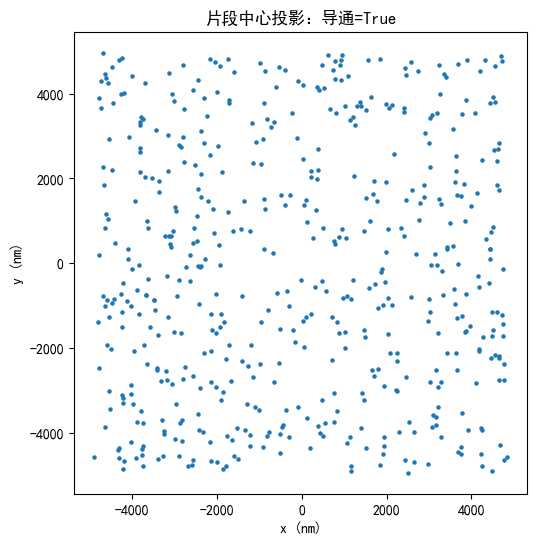

In [19]:
 # 简单可视化：xy 平面投影的圆心与连通簇（仅示意）
centers = np.array([s.center() for s in segments])
xs = centers[:,0]
ys = centers[:,1]
plt.figure(figsize=(6,6))
plt.scatter(xs, ys, s=5)
plt.xlabel('x (nm)')
plt.ylabel('y (nm)')
plt.title(f'片段中心投影：导通={connected}')
plt.gca().set_aspect('equal', 'box')
plt.show()

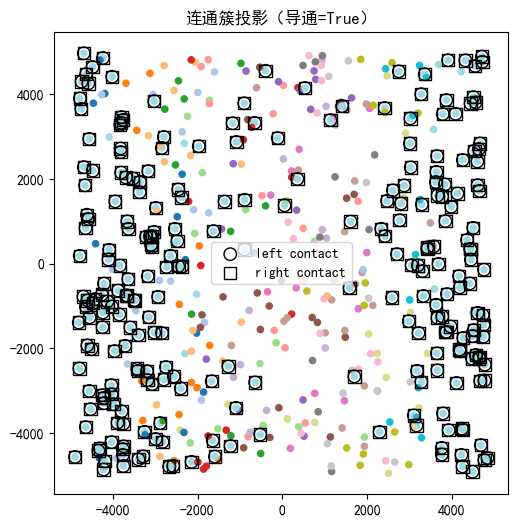

In [20]:
# 为每个片段/原粒子着色显示连通簇（示意）
# 先收集 segments、uf（notebook 中已有 segments, uf, connected）
labels = []
for idx, s in enumerate(segments):
    labels.append(uf.find(idx))
# 把标签压缩成连续整数用于调色
unique = {v:i for i,v in enumerate(sorted(set(labels), key=lambda x: str(x)))}
colors = [unique[l] for l in labels]
centers = np.array([s.center() for s in segments])
plt.figure(figsize=(6,6))
plt.scatter(centers[:,0], centers[:,1], c=colors, s=20, cmap='tab20')
# 标示连接到左右平面的点
left_pts = [i for i,s in enumerate(segments) if uf.find(i) == uf.find(('PLANE','LEFT'))]
right_pts = [i for i,s in enumerate(segments) if uf.find(i) == uf.find(('PLANE','RIGHT'))]
if left_pts:
    plt.scatter(centers[left_pts,0], centers[left_pts,1], edgecolor='k', facecolor='none', s=80, label='left contact')
if right_pts:
    plt.scatter(centers[right_pts,0], centers[right_pts,1], marker='s', edgecolor='k', facecolor='none', s=80, label='right contact')
plt.legend()
plt.title(f'连通簇投影（导通={connected}）')
plt.gca().set_aspect('equal', 'box')
plt.show()

In [ ]:
import os
import numpy as np
import pandas as pd
from src.geometry import Cylinder
from src.truncation import split_cylinder_by_box
from src.connectivity import build_connectivity

# 参数
L = 10000.0
half = L / 2.0
r_A = 30.0
thresh = 1.8

def check_group(file_name):
    """检查单个附件组的导通情况"""
    csv_path = os.path.join(repo_root, 'data/raw', file_name)
    df = pd.read_csv(csv_path, encoding='gbk', header=1)
    df.columns = pd.MultiIndex.from_tuples([
        ('顶点1', 'X'), ('顶点1', 'Y'), ('顶点1', 'Z'),
        ('顶点2', 'X'), ('顶点2', 'Y'), ('顶点2', 'Z')
    ])
    
    # 构建圆柱列表
    cylinders = []
    for idx, row in df.iterrows():
        p1 = np.array([row[('顶点1', 'X')], row[('顶点1', 'Y')], row[('顶点1', 'Z')]])
        p2 = np.array([row[('顶点2', 'X')], row[('顶点2', 'Y')], row[('顶点2', 'Z')]])
        cylinders.append(Cylinder(p1, p2, r_A, id=idx))
    
    # 截断
    segments = []
    for c in cylinders:
        segs = split_cylinder_by_box(c, L)
        segments.extend(segs)
    
    print(f"{file_name}: 原始圆柱 {len(cylinders)} 根，截断后片段 {len(segments)} 个")
    
    # 连通性判定
    connected, uf = build_connectivity(segments, L, thresh)
    print(f"  -> 导通: {connected}")
    
    return connected, segments, uf

# 检查三个组
for i in range(1, 4):
    file_name = f"附件_组{i}.csv"
    print(f"\n--- 检查 {file_name} ---")
    check_group(file_name)


--- 检查 附件_组1.csv ---
附件_组1.csv: 原始圆柱 12 根，截断后片段 12 个
  -> 导通: False

--- 检查 附件_组2.csv ---
附件_组2.csv: 原始圆柱 49 根，截断后片段 49 个
  -> 导通: False

--- 检查 附件_组3.csv ---
附件_组3.csv: 原始圆柱 535 根，截断后片段 535 个
  -> 导通: False


In [ ]:
from src.geometry import Cylinder
from src.truncation import split_cylinder_by_box
import numpy as np

# 构造一根跨右边界的圆柱（从 x=4000 到 x=7000）
c = Cylinder(np.array([4000, 0, 0]), np.array([7000, 0, 0]), 30.0, id=0)
segs = split_cylinder_by_box(c, 10000.0)
print(f"截断后片段数: {len(segs)}")
for seg in segs:
    print(f"  {seg.p0} -> {seg.p1}")

截断后片段数: 2
  [4000.    0.    0.] -> [5000.    0.    0.]
  [-5000.     0.     0.] -> [-3000.     0.     0.]


In [ ]:
import pandas as pd
import numpy as np

csv_path = os.path.join(repo_root, 'data/raw/附件_组1.csv')
df = pd.read_csv(csv_path, encoding='gbk', header=1)
df.columns = pd.MultiIndex.from_tuples([
    ('顶点1', 'X'), ('顶点1', 'Y'), ('顶点1', 'Z'),
    ('顶点2', 'X'), ('顶点2', 'Y'), ('顶点2', 'Z')
])

# 查看坐标范围
for col in ['X', 'Y', 'Z']:
    all_vals = pd.concat([df[('顶点1', col)], df[('顶点2', col)]])
    print(f"{col}: min={all_vals.min():.1f}, max={all_vals.max():.1f}")

X: min=-5000.0, max=5000.0
Y: min=-500.0, max=420.2
Z: min=-500.0, max=500.0


In [ ]:
from src.connectivity import build_connectivity

# 对组1进行连通性判定
connected, uf = build_connectivity(segments, 10000.0, 1.8)

# 检查有多少片段接触电极
left_contacts = []
right_contacts = []
for i, seg in enumerate(segments):
    xs = np.array([seg.p0[0], seg.p1[0]])
    if xs.min() - (-5000) <= 1.8 + 30.0:
        left_contacts.append(i)
    if 5000 - xs.max() <= 1.8 + 30.0:
        right_contacts.append(i)

print(f"接触左电极的片段数: {len(left_contacts)}")
print(f"接触右电极的片段数: {len(right_contacts)}")

接触左电极的片段数: 92
接触右电极的片段数: 90


In [ ]:
# 检查左右电极是否在同一个并查集集合中
left_node = ("PLANE", "LEFT")
right_node = ("PLANE", "RIGHT")

try:
    left_root = uf.find(left_node)
    right_root = uf.find(right_node)
    print(f"左电极根节点: {left_root}")
    print(f"右电极根节点: {right_root}")
    print(f"是否连通: {left_root == right_root}")
except Exception as e:
    print(f"错误: {e}")
    print("可能左右电极节点没有在并查集中初始化")

左电极根节点: 91
右电极根节点: 534
是否连通: False


# 修正"电连接"逻辑所做的测试

In [ ]:
from src.geometry import Cylinder
from src.truncation import split_cylinder_by_box
import numpy as np

# 构造跨边界圆柱
c = Cylinder(np.array([4000, 0, 0]), np.array([7000, 0, 0]), 30.0, id=0)
segs = split_cylinder_by_box(c, 10000.0)
print(f"截断后片段数: {len(segs)}")
for seg in segs:
    print(f"  {seg.p0} -> {seg.p1}, id={seg.id}")
    print(f"    截断后片段是否保留了 id: {seg.id is not None}")

截断后片段数: 2
  [4000.    0.    0.] -> [5000.    0.    0.], id=0
    截断后片段是否保留了 id: True
  [-5000.     0.     0.] -> [-3000.     0.     0.], id=0
    截断后片段是否保留了 id: True


In [ ]:
from src.geometry import cylinder_surface_distance

if len(segs) == 2:
    # 两个片段之间的距离
    dist = cylinder_surface_distance(segs[0], segs[1])
    print(f"两个片段之间的表面距离: {dist} nm")
    print(f"是否导通 (≤ 1.8): {dist <= 1.8}")

两个片段之间的表面距离: 6940.0 nm
是否导通 (≤ 1.8): False


In [ ]:
from src.geometry import Cylinder, cylinder_surface_distance
import numpy as np

# 生成 100 根随机圆柱
L = 10000.0
r = 30.0
h = 5000.0
seed = 20260812
N = 100

rng = np.random.default_rng(seed)
centers = rng.uniform(-L/2, L/2, size=(N, 3))
dirs = rng.normal(size=(N, 3))
norms = np.linalg.norm(dirs, axis=1, keepdims=True)
dirs = dirs / norms

cyls = []
for i in range(N):
    p0 = centers[i] - dirs[i] * h/2
    p1 = centers[i] + dirs[i] * h/2
    cyls.append(Cylinder(p0, p1, r, id=i))

# 检查前 10 根圆柱之间的距离
for i in range(10):
    for j in range(i+1, 10):
        dist = cylinder_surface_distance(cyls[i], cyls[j])
        if dist <= 1.8:
            print(f"圆柱 {i} 和 {j} 表面距离 {dist:.3f} nm，导通！")

In [ ]:
from src.geometry import Cylinder, cylinder_surface_distance
import numpy as np

L = 10000.0
r = 30.0
h = 5000.0
seed = 20260812
N = 100

rng = np.random.default_rng(seed)
centers = rng.uniform(-L/2, L/2, size=(N, 3))
dirs = rng.normal(size=(N, 3))
norms = np.linalg.norm(dirs, axis=1, keepdims=True)
dirs = dirs / norms

cyls = []
for i in range(N):
    p0 = centers[i] - dirs[i] * h/2
    p1 = centers[i] + dirs[i] * h/2
    cyls.append(Cylinder(p0, p1, r, id=i))

# 检查前 10 根圆柱的距离分布
distances = []
for i in range(10):
    for j in range(i+1, 10):
        dist = cylinder_surface_distance(cyls[i], cyls[j])
        distances.append(dist)
        if dist <= 1.8:
            print(f"圆柱 {i} 和 {j} 表面距离 {dist:.3f} nm，导通！")

if distances:
    print(f"\n共检查 {len(distances)} 对圆柱")
    print(f"最小表面距离: {min(distances):.3f} nm")
    print(f"最大表面距离: {max(distances):.3f} nm")
    print(f"平均表面距离: {np.mean(distances):.3f} nm")
    print(f"≤ 1.8 nm 的对数: {sum(1 for d in distances if d <= 1.8)}")


共检查 45 对圆柱
最小表面距离: 807.635 nm
最大表面距离: 11294.550 nm
平均表面距离: 5391.729 nm
≤ 1.8 nm 的对数: 0


In [ ]:
from src.truncation import split_cylinder_by_box
from src.geometry import Cylinder
import numpy as np

L = 10000.0
half = L / 2.0

# 测试一根跨边界圆柱
c = Cylinder(np.array([4000, 0, 0]), np.array([7000, 0, 0]), 30.0, id=0)
segs = split_cylinder_by_box(c, L)

print(f"片段数: {len(segs)}")
for seg in segs:
    print(f"  片段: {seg.p0} -> {seg.p1}")
    # 检查是否在盒内
    in_box = all(-half <= x <= half for x in seg.p0) and all(-half <= x <= half for x in seg.p1)
    print(f"    在盒内: {in_box}")

片段数: 2
  片段: [4000.    0.    0.] -> [5000.    0.    0.]
    在盒内: True
  片段: [-5000.     0.     0.] -> [-3000.     0.     0.]
    在盒内: True


In [ ]:
from src.geometry import Cylinder, cylinder_surface_distance
import numpy as np

# 圆柱1：沿 X 轴，从 (0,0,0) 到 (5000,0,0)
c1 = Cylinder(np.array([0,0,0]), np.array([5000,0,0]), 30.0, id=0)
# 圆柱2：沿 X 轴，从 (0,60,0) 到 (5000,60,0)，轴线距离 60nm
c2 = Cylinder(np.array([0,60,0]), np.array([5000,60,0]), 30.0, id=1)

dist = cylinder_surface_distance(c1, c2)
print(f"表面距离: {dist}")  # 应为 0.0

表面距离: 0.0


In [ ]:
c2 = Cylinder(np.array([0,100,0]), np.array([5000,100,0]), 30.0, id=1)
dist = cylinder_surface_distance(c1, c2)
print(f"表面距离: {dist}")  # 应为 100 - 60 = 40

表面距离: 40.0


In [ ]:
from src.geometry import Cylinder
from src.truncation import split_cylinder_by_box
from src.connectivity import build_connectivity
import numpy as np

L = 10000.0
r = 30.0
thresh = 1.8

# 构造一根从左电极到右电极的圆柱（完全在盒内，不跨边界）
c = Cylinder(np.array([-5000, 0, 0]), np.array([5000, 0, 0]), r, id=0)
segments = split_cylinder_by_box(c, L)  # 应该返回一个片段（因为不跨边界）
connected, uf = build_connectivity(segments, L, thresh)
print(f"单根横跨圆柱导通: {connected}")  # 应为 True

单根横跨圆柱导通: True


In [ ]:
# 两根圆柱首尾相接，形成从左到右的路径
c1 = Cylinder(np.array([-5000, 0, 0]), np.array([0, 0, 0]), r, id=0)
c2 = Cylinder(np.array([0, 0, 0]), np.array([5000, 0, 0]), r, id=1)
# 它们正好在原点接触（轴线距离0，表面距离 -60，但max(0)后为0）
segments = split_cylinder_by_box(c1, L) + split_cylinder_by_box(c2, L)
connected, uf = build_connectivity(segments, L, thresh)
print(f"两根首尾相接圆柱导通: {connected}")  # 应为 True

两根首尾相接圆柱导通: False


In [ ]:
from src.geometry import Cylinder
from src.truncation import split_cylinder_by_box
from src.connectivity import build_connectivity
import numpy as np

L = 10000.0
r = 30.0
thresh = 1.8

c1 = Cylinder(np.array([-5000, 0, 0]), np.array([0, 0, 0]), r, id=0)
c2 = Cylinder(np.array([0, 0, 0]), np.array([5000, 0, 0]), r, id=1)

segments = split_cylinder_by_box(c1, L) + split_cylinder_by_box(c2, L)

print(f"片段数: {len(segments)}")
for i, s in enumerate(segments):
    print(f"  片段 {i}: {s.p0} -> {s.p1}")
    lo, hi = s.aabb()
    print(f"    AABB: lo={lo}, hi={hi}")

# 手动计算两个片段的表面距离
from src.geometry import cylinder_surface_distance
dist = cylinder_surface_distance(segments[0], segments[1])
print(f"\n两个片段的表面距离: {dist} nm")

# 手动检查 AABB 是否重叠
lo0, hi0 = segments[0].aabb()
lo1, hi1 = segments[1].aabb()
overlap = not (np.any(lo0 > hi1) or np.any(lo1 > hi0))
print(f"AABB 重叠: {overlap}")

片段数: 2
  片段 0: [-5000.     0.     0.] -> [0. 0. 0.]
    AABB: lo=[-5030.   -30.   -30.], hi=[30. 30. 30.]
  片段 1: [0. 0. 0.] -> [5000.    0.    0.]
    AABB: lo=[-30. -30. -30.], hi=[5030.   30.   30.]

两个片段的表面距离: 0.0 nm
AABB 重叠: True


In [ ]:
from src.connectivity import _grid_index
import numpy as np

L = 10000.0
cell_size = max((2 * 30.0 + 1.8), L / 20.0)  # 和 build_connectivity 中的计算一致
print(f"cell_size: {cell_size}")

# 两个片段的中心
centers = [
    np.array([-2500.0, 0.0, 0.0]),  # 片段0的中心
    np.array([2500.0, 0.0, 0.0])     # 片段1的中心
]

# 计算网格索引
idx0 = _grid_index(centers[0], cell_size, L)
idx1 = _grid_index(centers[1], cell_size, L)
print(f"片段0的网格索引: {idx0}")
print(f"片段1的网格索引: {idx1}")

# 检查它们是否在相邻网格
neighs = [(dx, dy, dz) for dx in (-1, 0, 1) for dy in (-1, 0, 1) for dz in (-1, 0, 1)]
is_neighbor = (idx1[0] - idx0[0], idx1[1] - idx0[1], idx1[2] - idx0[2]) in neighs
print(f"是否在相邻网格: {is_neighbor}")

# 如果不在相邻网格，说明 cell_size 太大了

cell_size: 500.0
片段0的网格索引: (np.int64(5), np.int64(10), np.int64(10))
片段1的网格索引: (np.int64(15), np.int64(10), np.int64(10))
是否在相邻网格: False


In [4]:
import inspect
from src.connectivity import build_connectivity
print(inspect.getsource(build_connectivity))

def build_connectivity(particles: List, L: float, thresh: float = 1.8, left_plane_x: float = None, right_plane_x: float = None) -> Tuple[bool, UnionFind]:
    """
    particles: list of objects, each either Cylinder segments (Cylinder) or Sphere instances.
    For cylinders that were split, pass the resulting segments (each with .id).
    """
    if left_plane_x is None:
        left_plane_x = -L/2.0
    if right_plane_x is None:
        right_plane_x = L/2.0

    uf = UnionFind()
    LEFT_NODE = ("PLANE", "LEFT")
    RIGHT_NODE = ("PLANE", "RIGHT")
    uf.find(LEFT_NODE); uf.find(RIGHT_NODE)

    # Build id->indices mapping for same original id unioning
    #id_to_indices: Dict[int, List[int]] = {}
    #for idx, p in enumerate(particles):
    #    pid = getattr(p, 'id', None)
    #    id_to_indices.setdefault(pid, []).append(idx)
    #for inds in id_to_indices.values():
    #    first = inds[0]
    #    for other in inds[1:]:
    #        uf.union(first, other)

    # spatial hashing


In [2]:
from src.geometry import Cylinder
from src.truncation import split_cylinder_by_box
from src.connectivity import build_connectivity
import numpy as np

L = 10000.0
r = 30.0
thresh = 1.8

c1 = Cylinder(np.array([-5000, 0, 0]), np.array([0, 0, 0]), r, id=0)
c2 = Cylinder(np.array([0, 0, 0]), np.array([5000, 0, 0]), r, id=1)

segments = split_cylinder_by_box(c1, L) + split_cylinder_by_box(c2, L)
connected, uf = build_connectivity(segments, L, thresh)
print(f"两根首尾相接圆柱导通: {connected}")  # 应输出 True

两根首尾相接圆柱导通: True
